# Section 3: The Two-Country Model

This notebook reproduces the results and figures from Section 3 of *Trade Tariffs and Exchange Rates: Revisiting Conventional Wisdom in a Three-Country Framework* (Lu & Milkov 2026).

The two-country model establishes the **conventional wisdom**: a country that imposes import tariffs sees its currency appreciate in equilibrium. We derive this result, compute it numerically, and demonstrate its robustness.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tariff_exchange_rates import (
    make_params_2country,
    solve_2country,
    plot_tb_locus,
    compute_allocation,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 3.1 Model Setup

The economy has two countries ($A$ and $B$), two sectors (tradable $T$ and non-tradable $N$), and one factor of production (labor). Firms operate under perfect competition and linear technologies:

$$Y_{T_i} = A_{T_i} L_{T_i}, \qquad Y_{N_i} = A_{N_i} L_{N_i}$$

Producer prices are normalized to one ($P_{T_A} = P_{T_B} = 1$), so equilibrium wages satisfy $w_i = A_{T_i}$ and non-tradable prices are pinned down by $P_{N_i} = A_{T_i}/A_{N_i}$.

Households have **Cobb-Douglas** preferences over goods $T_A$, $T_B$, and $N$, with expenditure shares $\alpha_{T_A}$, $\alpha_{T_B}$, and $\alpha_N = 1 - \alpha_{T_A} - \alpha_{T_B}$.

The **nominal exchange rate** $e$ is defined as units of country $A$'s currency per unit of country $B$'s currency. Trade is balanced in equilibrium:

$$\mathrm{TB}_A = \underbrace{\alpha_{T_A} w_B L_B}_{\text{exports}} - \underbrace{\alpha_{T_B} \cdot e \cdot w_A L_A}_{\text{imports}} = 0$$

Under free trade, this pins down the equilibrium exchange rate:

$$e^* = \frac{\alpha_{T_A}}{\alpha_{T_B}} \cdot \frac{w_B L_B}{w_A L_A}$$

In [2]:
# Symmetric baseline calibration from the paper
# A_T = A_N = 1, L = 1, equal expenditure shares (1/3 each)
params = make_params_2country(
    alpha_T_A=1/3, alpha_T_B=1/3, alpha_N=1/3,
    productivity_T=(1.0, 1.0),
    productivity_N=(1.0, 1.0),
    labor=(1.0, 1.0),
)

# Free-trade equilibrium
eq_free = solve_2country(params, tau=0.0)
print(f"Free-trade equilibrium exchange rate: e* = {eq_free['e_AB']:.4f}")
print(f"(By symmetry, e* = 1 as expected)")

Free-trade equilibrium exchange rate: e* = 1.0000
(By symmetry, e* = 1 as expected)


## 3.2 Imposing Tariffs

Country $A$ levies an ad valorem tariff $\tau \geq 0$ on imports from $B$. The tariff raises the consumer price of $T_B$ in country $A$ to $(1+\tau)eP_{T_B}$. Revenue is rebated lump-sum to households, so disposable income becomes:

$$I_A = \frac{w_A L_A}{1 - \dfrac{\alpha_{T_B}\,\tau}{1+\tau}}$$

Substituting into the trade-balance condition and solving for $e$ yields the **closed-form exchange rate**:

$$e(\tau) = \frac{1}{1+\tau} \cdot \frac{1}{1 - \dfrac{\alpha_{T_B}\,\tau}{1+\tau}} \cdot \frac{\alpha_{T_B}}{\alpha_{T_A}} \cdot \frac{A_{T_A} L_A}{A_{T_B} L_B}$$

This is **strictly decreasing** in $\tau$: higher tariffs require an appreciation of country $A$'s currency to restore trade balance.

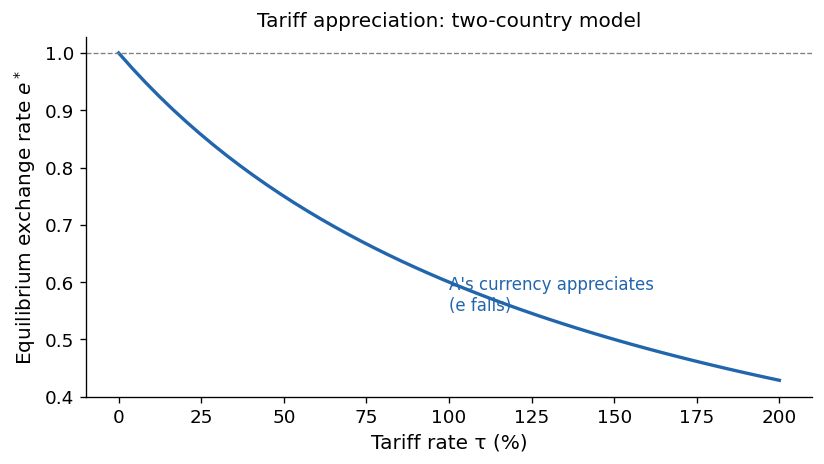

Selected equilibria:
  τ = 0.00  →  e* = 1.0000  (-0.0% vs free trade)
  τ = 0.20  →  e* = 0.8824  (-11.8% vs free trade)
  τ = 0.50  →  e* = 0.7500  (-25.0% vs free trade)
  τ = 1.00  →  e* = 0.6000  (-40.0% vs free trade)
  τ = 1.50  →  e* = 0.5000  (-50.0% vs free trade)
  τ = 2.00  →  e* = 0.4286  (-57.1% vs free trade)


In [3]:
# Solve equilibrium across a range of tariff rates
taus = np.linspace(0, 2.0, 50)
e_stars = [solve_2country(params, tau=t)["e_AB"] for t in taus]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(taus * 100, e_stars, color="#2166ac", linewidth=2)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Free-trade baseline")
ax.set_xlabel("Tariff rate τ (%)", fontsize=12)
ax.set_ylabel("Equilibrium exchange rate $e^*$", fontsize=12)
ax.set_title("Tariff appreciation: two-country model", fontsize=12)
ax.annotate("A's currency appreciates\n(e falls)", xy=(100, 0.55), fontsize=10, color="#2166ac")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("Selected equilibria:")
for t in [0.0, 0.20, 0.50, 1.0, 1.5, 2.0]:
    e = solve_2country(params, tau=t)["e_AB"]
    print(f"  τ = {t:.2f}  →  e* = {e:.4f}  ({100*(e-1):.1f}% vs free trade)")

## 3.3 Trade Balance Locus (Figure 1)

The figure below reproduces **Figure 1** from the paper. It plots country $A$'s trade balance as a function of the log exchange rate for three tariff rates. The equilibrium is where the curve crosses zero.

A higher tariff **shifts the locus upward** at any given exchange rate — reflecting the reduction in import demand — so equilibrium requires a lower $e$ (appreciation of $A$'s currency).

Saved: ../output/2c2s1f_with_tariffs_eq.pdf


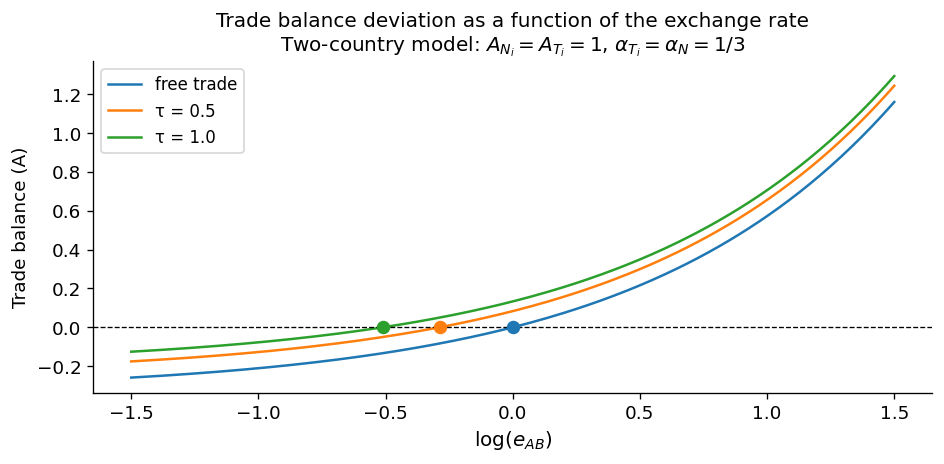

In [4]:
plot_tb_locus(
    params,
    taus=[0.0, 0.5, 1.0],
    log_e_range=(-1.5, 1.5),
    title="Trade balance deviation as a function of the exchange rate\n"
          r"Two-country model: $A_{N_i}=A_{T_i}=1$, $\alpha_{T_i}=\alpha_N=1/3$",
    pdf_name="../output/2c2s1f_with_tariffs_eq.pdf",
)

## 3.4 Robustness of the Appreciation Result

The closed-form result relies on Cobb-Douglas preferences and linear technology. The paper shows this is not essential — the sign $de/d\tau < 0$ follows from general **monotonicity conditions**:

1. **Tariff monotonicity** (Lemma 1): A tariff compresses import expenditure at a fixed exchange rate ($\mathrm{TB}_{A,\tau} > 0$), as long as import demand is decreasing in the consumer import price.

2. **Exchange-rate monotonicity** (Lemma 2): A depreciation of $A$'s currency improves its trade balance ($\mathrm{TB}_{A,e} > 0$), as long as higher $e$ reduces imports and weakly increases exports.

By the implicit function theorem: $de/d\tau = -\mathrm{TB}_{A,\tau}/\mathrm{TB}_{A,e} < 0$.

We verify this numerically across a range of CES elasticities $\sigma$.

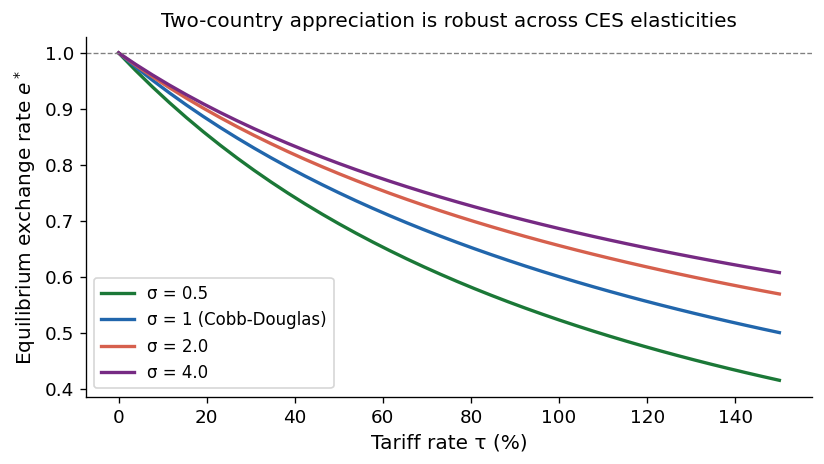

In all cases, higher tariffs → lower e* (currency appreciation). Sign is robust.


In [5]:
# Robustness: appreciation holds across all elasticities of substitution
sigmas = [0.5, 1.0, 2.0, 4.0]
tau_grid = np.linspace(0, 1.5, 40)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#1b7837", "#2166ac", "#d6604d", "#762a83"]

for sigma, color in zip(sigmas, colors):
    p = make_params_2country(alpha_T_A=1/3, alpha_T_B=1/3, alpha_N=1/3, sigma=sigma)
    e_vals = [solve_2country(p, tau=t)["e_AB"] for t in tau_grid]
    ax.plot(tau_grid * 100, e_vals, color=color, linewidth=2,
            label=f"σ = {sigma}" if sigma != 1.0 else "σ = 1 (Cobb-Douglas)")

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Tariff rate τ (%)", fontsize=12)
ax.set_ylabel("Equilibrium exchange rate $e^*$", fontsize=12)
ax.set_title("Two-country appreciation is robust across CES elasticities", fontsize=12)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("In all cases, higher tariffs → lower e* (currency appreciation). Sign is robust.")

## 3.5 Channels of Adjustment

To build intuition for the three-country generalization in Section 4, it helps to decompose **why** the two-country appreciation result is so robust.

When country $A$ imposes tariff $\tau$ on $B$'s goods:
- The consumer price of $T_B$ rises in $A$, so demand for $T_B$ falls
- Expenditure switches toward domestic good $T_A$ and non-tradable $N_A$
- $A$'s trade balance improves at the prevailing exchange rate
- In equilibrium, $A$'s currency appreciates to restore balance

The key observation: **all substitution occurs between domestic goods and the foreign good**. There is no third country to absorb diverted imports. This is precisely what changes in Section 4.

In [6]:
# Decompose trade flow changes as tau rises
taus_select = [0.0, 0.20, 0.50, 1.0, 1.5]
rows = []
for tau in taus_select:
    eq = solve_2country(params, tau=tau)
    alloc = eq["allocation"]
    e = eq["e_AB"]
    # Exports = C_TA consumed in B (in A's currency)
    exports = alloc["demand_T"][1, 0] * e   # B's demand for A's good, valued in A's currency
    # Imports = C_TB consumed in A (consumer price x quantity)
    imports = alloc["consumer_prices"][0, 1] * alloc["demand_T"][0, 1]
    rows.append({
        "τ": f"{tau:.0%}",
        "e*": f"{e:.4f}",
        "% Δe vs FT": f"{100*(e/e_stars[0]-1):.1f}%",
        "A imports (TB units)": f"{alloc['trade_balance'][0]:.4f}",
        "A income I_A": f"{alloc['income'][0]:.4f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

   τ     e* % Δe vs FT A imports (TB units) A income I_A
  0% 1.0000       0.0%              -0.0000       1.0000
 20% 0.8824     -11.8%               0.0000       1.0588
 50% 0.7500     -25.0%               0.0000       1.1250
100% 0.6000     -40.0%              -0.0000       1.2000
150% 0.5000     -50.0%               0.0000       1.2500


## Summary

The two-country model delivers a clean, robust prediction:

> **Conventional wisdom**: A country that imposes import tariffs sees its currency appreciate in equilibrium, regardless of the elasticity of substitution, production technology, or treatment of tariff revenue.

The mechanism is straightforward: tariffs reduce imports at the prevailing exchange rate, improving the trade balance. Since equilibrium requires balanced trade, the exchange rate must adjust — and in a two-country world, that means appreciation.

**The key limitation**: in a two-country world, the only margin of substitution is between domestic goods and the foreign good. In Section 4, we introduce a third country and show that this changes everything.